# Assignment 2 by: Shambhavi Tewari (s4016395)

## Loading the data 

In [1]:
# codes to ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load the CSV data
data = pd.read_csv('A2data.csv', delimiter=';')

In [3]:
data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45,170,1.001,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14,132,0.994,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30,97,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47,186,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47,186,0.9956,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4776,6.2,0.21,0.29,1.6,0.039,24,92,0.99114,3.27,0.50,11.2,6
4777,6.6,0.32,0.36,8,0.047,57,168,0.9949,3.15,0.46,9.6,5
4778,6.5,0.24,0.19,1.2,0.041,30,111,0.99254,2.99,0.46,9.4,6
4779,5.5,0.29,0.30,1.1,0.022,20,110,0.98869,3.34,0.38,12.8,7


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4781 entries, 0 to 4780
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4781 non-null   float64
 1   volatile acidity      4780 non-null   float64
 2   citric acid           4776 non-null   float64
 3   residual sugar        4776 non-null   object 
 4   chlorides             4780 non-null   float64
 5   free sulfur dioxide   4778 non-null   object 
 6   total sulfur dioxide  4778 non-null   object 
 7   density               4774 non-null   object 
 8   pH                    4780 non-null   float64
 9   sulphates             4779 non-null   float64
 10  alcohol               4781 non-null   float64
 11  quality               4781 non-null   int64  
dtypes: float64(7), int64(1), object(4)
memory usage: 448.3+ KB


In [5]:
import pandas as pd

data['residual sugar'] = pd.to_numeric(data['residual sugar'], errors='coerce')
data['free sulfur dioxide'] = pd.to_numeric(data['free sulfur dioxide'], errors='coerce')
data['total sulfur dioxide'] = pd.to_numeric(data['total sulfur dioxide'], errors='coerce')
data['density'] = pd.to_numeric(data['density'], errors='coerce')

# Check the updated data types
print(data.dtypes)

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object


# Task 1: Regression


In [6]:
# Take a random sample of 200 rows with no missing values
sample = data.dropna().sample(n=200, random_state=42)

In [7]:
sample.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [8]:
# Write the random sample to a new CSV file
sample.to_csv('s4016395-A2SampleOne.csv', index=False)

In [9]:
# Select the columns 'alcohol' and 'density'
sample['alcohol'] = pd.to_numeric(sample['alcohol'], errors='coerce')
sample['density'] = pd.to_numeric(sample['density'], errors='coerce')

# Drop any rows where 'alcohol' or 'density' is NaN
sample = sample.dropna(subset=['alcohol', 'density'])

alcohol = sample['alcohol']
density = sample['density']

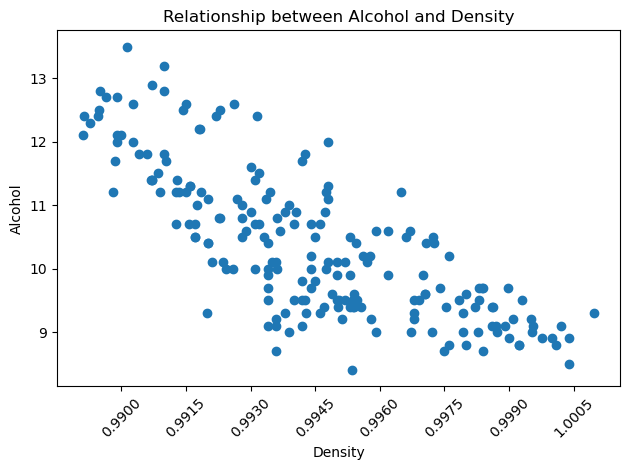

In [10]:
import matplotlib.ticker as ticker
plt.scatter(density, alcohol)
plt.xlabel('Density')
plt.ylabel('Alcohol')
plt.title('Relationship between Alcohol and Density')
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(10))  # Adjust '10' to control the number of ticks
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.4f}'))  # Round density values
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# Build a Simple Linear Regression model
# Reshape density to fit the model
X = np.array(density).reshape(-1, 1)
y = np.array(alcohol)

# Create and fit the model
model = LinearRegression()
model.fit(X, y)

# Display the coefficients of the linear model
print(f'Intercept: {model.intercept_}')
print(f'Slope: {model.coef_[0]}')

Intercept: 319.27119835721066
Slope: -310.62930326961924


Intercept: 319.27119835721066
Slope: -310.62930326961924
R-squared: 0.5992
Mean Squared Error (MSE): 0.5366
Root Mean Squared Error (RMSE): 0.7325
Mean Absolute Error (MAE): 0.5743


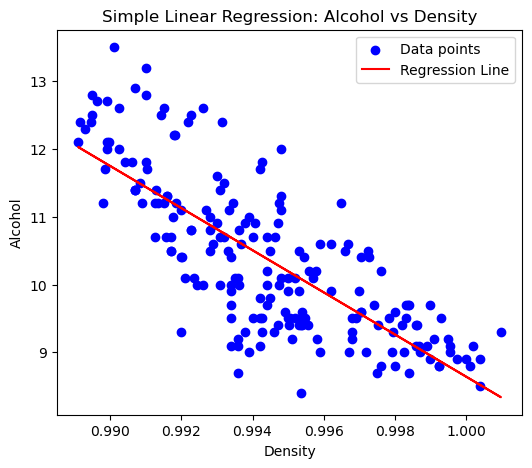

In [12]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Assuming you have already loaded your dataset
# For this example, I'll assume 'sample' contains the cleaned data with 'alcohol' and 'density' columns.

# Extract the independent and dependent variables
X = sample['density'].values.reshape(-1, 1)  # Independent variable (density)
y = sample['alcohol'].values  # Dependent variable (alcohol)

# Step 1: Create and fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Step 2: Make predictions using the model
y_pred = model.predict(X)

# Step 3: Print the coefficients of the linear model
print(f'Intercept: {model.intercept_}')
print(f'Slope: {model.coef_[0]}')

# Step 4: Evaluate the model
r_squared = r2_score(y, y_pred)  # R-squared value
mse = mean_squared_error(y, y_pred)  # Mean Squared Error
rmse = np.sqrt(mse)  # Root Mean Squared Error
mae = mean_absolute_error(y, y_pred)  # Mean Absolute Error

# Print evaluation metrics
print(f'R-squared: {r_squared:.4f}')
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')

# Step 5: Plot the data points and the regression line
plt.figure(figsize=(6,5))
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, y_pred, color='red', label='Regression Line')
plt.xlabel('Density')
plt.ylabel('Alcohol')
plt.title('Simple Linear Regression: Alcohol vs Density')
plt.legend()
plt.show()

# Task 2: Classification

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Take a random sample of 1000 instances
sample2 = data.dropna().sample(n=1000, random_state=42)

# Save the sample to a CSV file
sample2.to_csv('s4016395-A2SampleTwo.csv', index=False)

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_selection import SelectKBest, f_classif

X = sample2.drop(columns=['quality'])
X = X.dropna()
y = sample2['quality']

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) 

# Feature selection using SelectKBest (f_classif)
selector = SelectKBest(score_func=f_classif, k=5)  # Select top 5 features
X_top = selector.fit_transform(X_scaled, y)

# Train-test split for scaled and KBest
X_train_top, X_test_top, Y_train, Y_test = train_test_split(X_top, y, test_size=0.25, random_state=0)

# Now split the cleaned data into train and test sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
y_train.value_counts()

6    349
5    257
7    136
8     29
4     25
3      3
9      1
Name: quality, dtype: int64

In [16]:
y_test.value_counts()

6    92
5    64
7    33
8     5
4     4
9     1
3     1
Name: quality, dtype: int64

## kNN

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize kNN model with k=5 (or choose another k value based on experimentation)
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train, y_train)

# Make predictions
y_pred_knn = knn.predict(X_test)

# Evaluate the model
print(f'kNN Accuracy: {accuracy_score(y_test, y_pred_knn)}')
print(classification_report(y_test, y_pred_knn, zero_division=0))

kNN Accuracy: 0.47
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         4
           5       0.41      0.56      0.48        64
           6       0.54      0.57      0.55        92
           7       0.46      0.18      0.26        33
           8       0.00      0.00      0.00         5
           9       0.00      0.00      0.00         1

    accuracy                           0.47       200
   macro avg       0.20      0.19      0.18       200
weighted avg       0.46      0.47      0.45       200



In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Initialize the kNN classifier
knn = KNeighborsClassifier()

# Define a parameter grid for tuning
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],  # Number of neighbors to consider
    'weights': ['uniform', 'distance'],  # Uniform or distance-based weighting
    'metric': ['euclidean', 'manhattan', 'minkowski'],  # Different distance metrics
    'p': [1, 2]  # This is the power parameter for the Minkowski metric (p=1 for Manhattan, p=2 for Euclidean)
}

# Use GridSearchCV for parameter tuning
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', verbose=1)

# Fit the model
grid_search.fit(X_train, y_train)

# Get the best parameters and model
best_params = grid_search.best_params_
best_knn = grid_search.best_estimator_

print(f"Best parameters found: {best_params}")

# Evaluate the tuned kNN model
y_pred = best_knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Tuned kNN Accuracy: {accuracy:.4f}')

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best parameters found: {'metric': 'manhattan', 'n_neighbors': 9, 'p': 1, 'weights': 'distance'}
Tuned kNN Accuracy: 0.5400


## modified kNN 

In [19]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score

# Apply PCA to reduce the dimensionality of the dataset
pca = PCA(n_components=5)  # Retain the top 5 principal components (or adjust based on your data)
X_train_pca = pca.fit_transform(X_train_top)
X_test_pca = pca.transform(X_test_top)

# Initialize and train the kNN model with PCA-transformed data using the best parameters found
knn_pca = KNeighborsClassifier(n_neighbors=9, metric='manhattan', p=1, weights='distance')
knn_pca.fit(X_train_pca, Y_train)

# Make predictions using kNN with PCA
y_pred_knn_pca = knn_pca.predict(X_test_pca)

# Evaluate the modified kNN model with PCA
accuracy_knn_pca = accuracy_score(Y_test, y_pred_knn_pca)
precision_knn_pca = precision_score(Y_test, y_pred_knn_pca, average='weighted', zero_division=0)
recall_knn_pca = recall_score(Y_test, y_pred_knn_pca, average='weighted', zero_division=0)
f1_knn_pca = f1_score(Y_test, y_pred_knn_pca, average='weighted', zero_division=0)

# Print the classification report for kNN with PCA
print(f'kNN with PCA Accuracy: {accuracy_knn_pca}')
print(classification_report(Y_test, y_pred_knn_pca, zero_division=0))

kNN with PCA Accuracy: 0.504
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         7
           5       0.52      0.57      0.54        83
           6       0.50      0.60      0.55       110
           7       0.44      0.30      0.36        40
           8       1.00      0.11      0.20         9
           9       0.00      0.00      0.00         1

    accuracy                           0.50       250
   macro avg       0.41      0.26      0.27       250
weighted avg       0.50      0.50      0.48       250



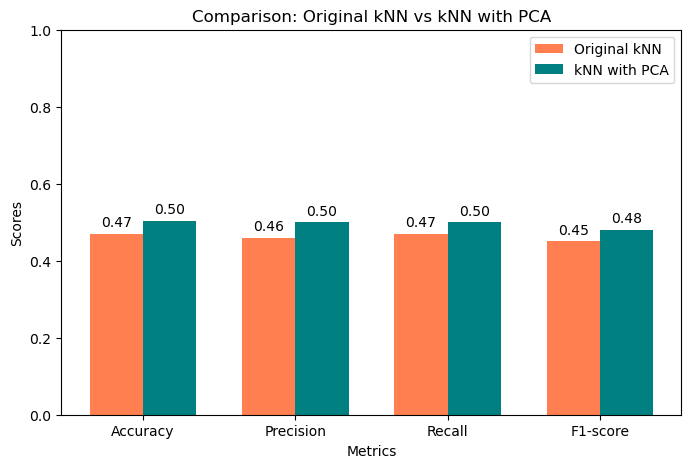

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics for original kNN model (use the actual values from your result)
accuracy_knn = 0.47
precision_knn = 0.46
recall_knn = 0.47
f1_knn = 0.45

# Metrics for kNN with PCA (replace with actual values)
accuracy_knn_pca = 0.504  # Example value from your PCA output
precision_knn_pca = 0.50  # Replace with actual value from PCA
recall_knn_pca = 0.50     # Replace with actual value from PCA
f1_knn_pca = 0.48         # Replace with actual value from PCA

# Define labels and plot settings
labels = ['Accuracy', 'Precision', 'Recall', 'F1-score']
knn_scores = [accuracy_knn, precision_knn, recall_knn, f1_knn]
knn_pca_scores = [accuracy_knn_pca, precision_knn_pca, recall_knn_pca, f1_knn_pca]

x = np.arange(len(labels))  # Label locations
width = 0.35  # Width of the bars

# Create the plot
fig, ax = plt.subplots(figsize=(8, 5))

# Plot kNN (n_neighbors=5) metrics
rects1 = ax.bar(x - width/2, knn_scores, width, label='Original kNN', color='coral')

# Plot kNN with PCA metrics
rects2 = ax.bar(x + width/2, knn_pca_scores, width, label='kNN with PCA', color='teal')

# Add labels, title, and custom x-axis tick labels
ax.set_xlabel('Metrics')
ax.set_ylabel('Scores')
ax.set_title('Comparison: Original kNN vs kNN with PCA')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Add text labels above the bars for better visualization
for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.ylim(0, 1)  # Set y-axis limits between 0 and 1 for clarity
plt.show()

## Decision Tree

In [21]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
tree = DecisionTreeClassifier(random_state=42)

# Define a parameter grid for tuning
param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 10, 20],
    'criterion': ['gini', 'entropy']
}

# Use StratifiedKFold instead of standard k-fold to ensure stratified splits
stratified_kfold = StratifiedKFold(n_splits=5)

# Use GridSearchCV with StratifiedKFold
grid_search = GridSearchCV(tree, param_grid, cv=stratified_kfold, scoring='accuracy', verbose=1)
grid_search.fit(X_train_top, Y_train)

# Get the best parameters and model
best_params = grid_search.best_params_
best_tree = grid_search.best_estimator_

print(f"Best parameters found: {best_params}")

# Train the best Decision Tree model
best_tree.fit(X_train_top, Y_train)

# Make predictions using the Decision Tree
y_pred_tree = best_tree.predict(X_test_top)

# Evaluate the Decision Tree model
accuracy_tree = accuracy_score(Y_test, y_pred_tree)
precision_tree = precision_score(Y_test, y_pred_tree, average='weighted', zero_division=0)
recall_tree = recall_score(Y_test, y_pred_tree, average='weighted', zero_division=0)
f1_tree = f1_score(Y_test, y_pred_tree, average='weighted', zero_division=0)

# Print the classification report for Decision Tree
print(f"Decision Tree Accuracy: {accuracy_tree:.4f}")
print(classification_report(Y_test, y_pred_tree, zero_division=0))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters found: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 20}
Decision Tree Accuracy: 0.5480
              precision    recall  f1-score   support

           4       0.50      0.14      0.22         7
           5       0.58      0.72      0.64        83
           6       0.53      0.63      0.57       110
           7       0.50      0.17      0.26        40
           8       0.00      0.00      0.00         9
           9       0.00      0.00      0.00         1

    accuracy                           0.55       250
   macro avg       0.35      0.28      0.28       250
weighted avg       0.52      0.55      0.51       250



### Comparison of Decision Trees with KNN

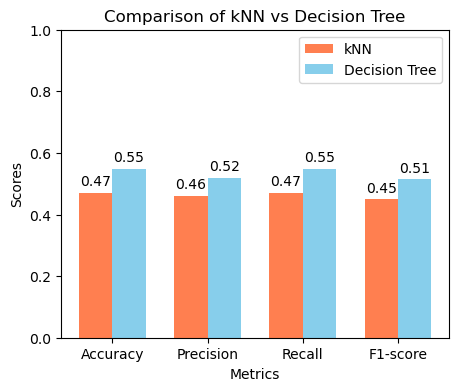

In [22]:
# Assuming you already have accuracy_knn, precision_knn, recall_knn, f1_knn calculated for the kNN model

# Metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
knn_scores = [accuracy_knn, precision_knn, recall_knn, f1_knn]
tree_scores = [accuracy_tree, precision_tree, recall_tree, f1_tree]

x = np.arange(len(metrics))  # Label locations
width = 0.35  # Width of the bars

# Plot the metrics
fig, ax = plt.subplots(figsize=(5, 4))
rects1 = ax.bar(x - width/2, knn_scores, width, label='kNN', color='coral')
rects2 = ax.bar(x + width/2, tree_scores, width, label='Decision Tree', color='skyblue')

# Add labels, title, and custom x-axis tick labels
ax.set_xlabel('Metrics')
ax.set_ylabel('Scores')
ax.set_title('Comparison of kNN vs Decision Tree')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Add the scores above the bars for better visualization
def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.ylim(0, 1)  # Set y-axis limits between 0 and 1 for clarity
plt.show()

# Task 3: Clustering

In [23]:
# Take a random sample of 300 instances
sample3 = data.dropna().sample(n=300, random_state=42)

# Save the random sample to a CSV file
sample3.to_csv('s4016395-A2SampleThree.csv', index=False)

# Display the shape of the sampled data to ensure it contains 300 rows
print(f"Shape of the random sample: {sample3.shape}")

Shape of the random sample: (300, 12)


## k-Means 

In [24]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Drop the 'quality' column for clustering
X = sample3.drop(columns=['quality'])

# Standardize the input variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Implement k-Means with an arbitrary number of clusters (e.g., k=3)
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

# Get cluster labels
cluster_labels = kmeans.labels_

# Add cluster labels to the dataset
sample3['cluster'] = cluster_labels

# Display the first few rows with cluster labels
print(sample3.head())

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
1593            7.5              0.19         0.49             1.6      0.047   
3192            6.6              0.16         0.34             1.1      0.037   
545             6.7              0.21         0.42             9.1      0.049   
2663            7.0              0.16         0.36             2.6      0.029   
4453            6.4              0.24         0.27             1.5      0.040   

      free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
1593                 42.0                 140.0  0.99320  3.40       0.47   
3192                 41.0                 115.0  0.98990  3.01       0.68   
545                  31.0                 150.0  0.99530  3.12       0.74   
2663                 28.0                  98.0  0.99126  3.11       0.37   
4453                 35.0                 105.0  0.98914  3.13       0.30   

      alcohol  quality  cluster  
1593     10.7   

In [25]:
from sklearn.metrics import silhouette_score

# Inertia (sum of squared distances to the closest cluster center)
inertia = kmeans.inertia_
print(f"Inertia: {inertia}")

# Silhouette Score
silhouette_avg = silhouette_score(X_scaled, cluster_labels)
print(f"Silhouette Score: {silhouette_avg}")

Inertia: 2294.296447070469
Silhouette Score: 0.15899882553306574


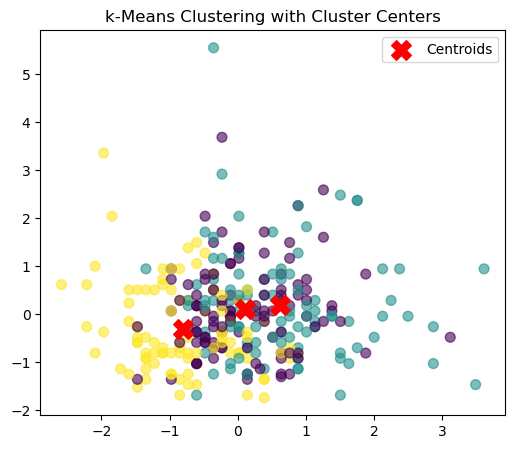

In [26]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Set the number of clusters (k)
k = 3  # or any other number of clusters you decide
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X_scaled)

# Get the cluster labels
labels = kmeans.labels_

# Plot the data points and color them based on cluster labels
plt.figure(figsize=(6,5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, s=50, cmap='viridis', alpha=0.6)

# Plot the cluster centers
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='red', label='Centroids', marker='X')

# Add title and labels
plt.title('k-Means Clustering with Cluster Centers')
plt.legend()
plt.show()

k	Inertia		Silhouette Score
2	2539.45		0.2206
3	2294.30		0.1590
4	2112.79		0.1623
5	1919.76		0.1402
6	1795.39		0.1604
7	1700.37		0.1343
8	1639.61		0.1373
9	1585.57		0.1209
10	1524.19		0.1211


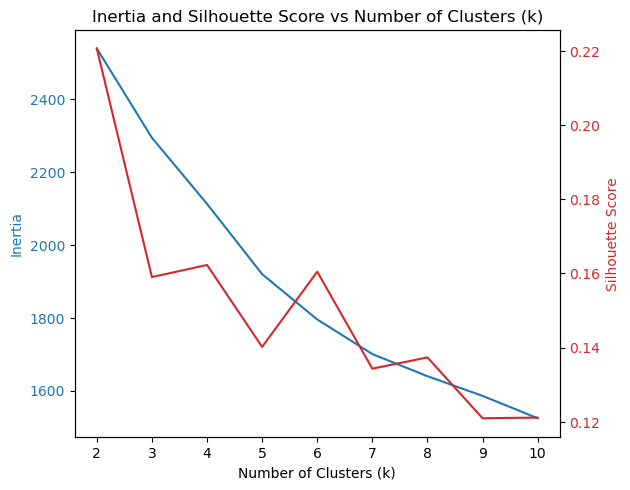

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# Define a range of values for k (e.g., 2 to 10)
k_values = range(2, 11)
inertias = []
silhouette_scores = []

print("k\tInertia\t\tSilhouette Score")
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    
    # Append inertia and silhouette score for each k
    inertia = kmeans.inertia_
    silhouette_avg = silhouette_score(X_scaled, kmeans.labels_)
    inertias.append(inertia)
    silhouette_scores.append(silhouette_avg)
    
    # Print the values for each k
    print(f"{k}\t{inertia:.2f}\t\t{silhouette_avg:.4f}")

# Plot Inertia (Elbow Method) and Silhouette Scores
fig, ax1 = plt.subplots()

ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia', color='tab:blue')
ax1.plot(k_values, inertias, label='Inertia', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.plot(k_values, silhouette_scores, label='Silhouette Score', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

fig.tight_layout()
plt.title('Inertia and Silhouette Score vs Number of Clusters (k)')
plt.show()

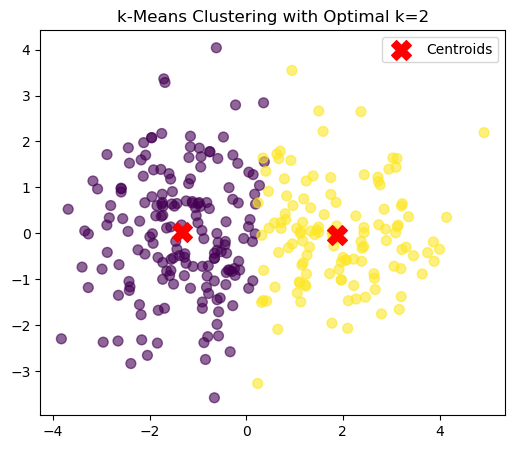

In [28]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


optimal_k = 2 # Set to 2 based on analysis
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42)
kmeans_optimal.fit(X_scaled)


labels_optimal = kmeans_optimal.labels_

# Performing PCA to reduce the dataset to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


plt.figure(figsize=(6,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_optimal, s=50, cmap='viridis', alpha=0.6)

centroids_pca = pca.transform(kmeans_optimal.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=200, c='red', label='Centroids', marker='X')

plt.title(f'k-Means Clustering with Optimal k={optimal_k}')
plt.legend()
plt.show()

In [29]:
from sklearn.metrics import calinski_harabasz_score

# Calculate the Calinski-Harabasz Index
ch_score = calinski_harabasz_score(X_scaled, labels_optimal)
print(f'Calinski-Harabasz Index for k-Means with k={optimal_k}: {ch_score}')

from sklearn.metrics import davies_bouldin_score

# Calculate the Davies-Bouldin Index
db_index = davies_bouldin_score(X_scaled, labels_optimal)
print(f'Davies-Bouldin Index for k-Means with k={optimal_k}: {db_index}')


Calinski-Harabasz Index for k-Means with k=2: 89.2497265712905
Davies-Bouldin Index for k-Means with k=2: 1.7125654562221606


## DBSCAN 

In [30]:
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import numpy as np
# Check the number of dimensions/features
num_dimensions = X.shape
print(f"Number of dimensions (features): {num_dimensions}")

Number of dimensions (features): (300, 11)


In [31]:
sample3

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,cluster
1593,7.5,0.19,0.49,1.6,0.047,42.0,140.0,0.99320,3.40,0.47,10.7,6,2
3192,6.6,0.16,0.34,1.1,0.037,41.0,115.0,0.98990,3.01,0.68,12.0,6,1
545,6.7,0.21,0.42,9.1,0.049,31.0,150.0,0.99530,3.12,0.74,9.9,7,0
2663,7.0,0.16,0.36,2.6,0.029,28.0,98.0,0.99126,3.11,0.37,11.2,7,1
4453,6.4,0.24,0.27,1.5,0.040,35.0,105.0,0.98914,3.13,0.30,12.4,6,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1905,7.1,0.25,0.28,1.6,0.052,46.0,169.0,0.99260,3.05,0.41,10.5,5,1
628,6.4,0.24,0.28,11.5,0.050,34.0,163.0,0.99690,3.31,0.45,9.5,5,0
136,5.6,0.16,0.27,1.4,0.044,53.0,168.0,0.99180,3.28,0.37,10.1,6,2
4226,6.0,0.33,0.26,5.1,0.051,16.0,119.0,0.99416,3.15,0.41,9.2,5,2


### Finding the optimal value of Minpts and Eps

In [32]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Loop over min_samples values from 1 to 5
for min_samples_value in range(2, 5):
    print(f"\n### DBSCAN with min_samples={min_samples_value} ###")
    
    # Loop over eps values from 0.1 to 3.0 with steps of 0.1
    for eps_value in np.arange(0.1, 2.1, 0.1):
        # Apply DBSCAN with the current eps and min_samples values
        dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
        dbscan_labels = dbscan.fit_predict(X_scaled)

        # Check the number of clusters and noise points
        unique_labels = np.unique(dbscan_labels)
        n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)  # Exclude noise (-1)
        n_noise = np.sum(dbscan_labels == -1)

        # Print the results for each eps and min_samples combination
        print(f"Eps: {eps_value:.1f}, MinPts: {min_samples_value} - Number of clusters: {n_clusters}, Number of noise points: {n_noise}")
        
        # If more than 1 cluster, calculate and print silhouette score (excluding noise)
        if n_clusters > 1:
            non_noise_points = dbscan_labels != -1
            silhouette_avg = silhouette_score(X_scaled[non_noise_points], dbscan_labels[non_noise_points])
            print(f"Silhouette Score for eps={eps_value:.1f}, MinPts={min_samples_value}: {silhouette_avg:.4f}")


### DBSCAN with min_samples=2 ###
Eps: 0.1, MinPts: 2 - Number of clusters: 3, Number of noise points: 294
Silhouette Score for eps=0.1, MinPts=2: 1.0000
Eps: 0.2, MinPts: 2 - Number of clusters: 4, Number of noise points: 292
Silhouette Score for eps=0.2, MinPts=2: 0.9927
Eps: 0.3, MinPts: 2 - Number of clusters: 5, Number of noise points: 290
Silhouette Score for eps=0.3, MinPts=2: 0.9856
Eps: 0.4, MinPts: 2 - Number of clusters: 5, Number of noise points: 290
Silhouette Score for eps=0.4, MinPts=2: 0.9856
Eps: 0.5, MinPts: 2 - Number of clusters: 5, Number of noise points: 290
Silhouette Score for eps=0.5, MinPts=2: 0.9856
Eps: 0.6, MinPts: 2 - Number of clusters: 7, Number of noise points: 286
Silhouette Score for eps=0.6, MinPts=2: 0.9369
Eps: 0.7, MinPts: 2 - Number of clusters: 9, Number of noise points: 282
Silhouette Score for eps=0.7, MinPts=2: 0.8911
Eps: 0.8, MinPts: 2 - Number of clusters: 13, Number of noise points: 274
Silhouette Score for eps=0.8, MinPts=2: 0.8071
Eps:

#### Best Parameter Combination: 
It seems that eps = 2 with min_samples = 3 provides the best balance between noise reduction and clustering quality.

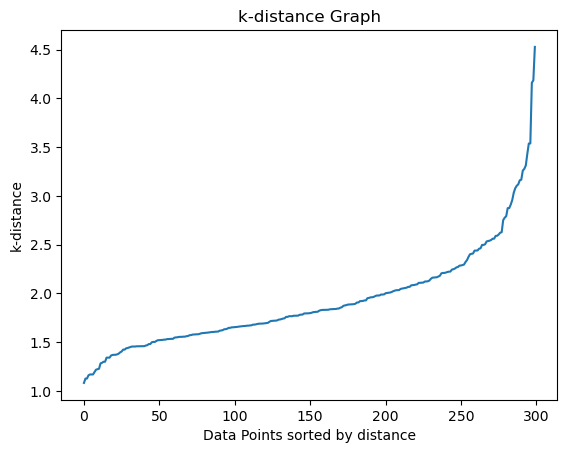

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# Define MinPts 
MinPts = 3

# Fit the nearest neighbors model
nbrs = NearestNeighbors(n_neighbors=MinPts).fit(X_scaled)  # X_scaled is the scaled data for DBSCAN
distances, indices = nbrs.kneighbors(X_scaled)

# Sort the distances for the k-th nearest neighbor
k_distances = np.sort(distances[:, MinPts-1])

# Plot the k-distance graph
plt.plot(k_distances)
plt.xlabel('Data Points sorted by distance')
plt.ylabel('k-distance')
plt.title('k-distance Graph')
plt.show()

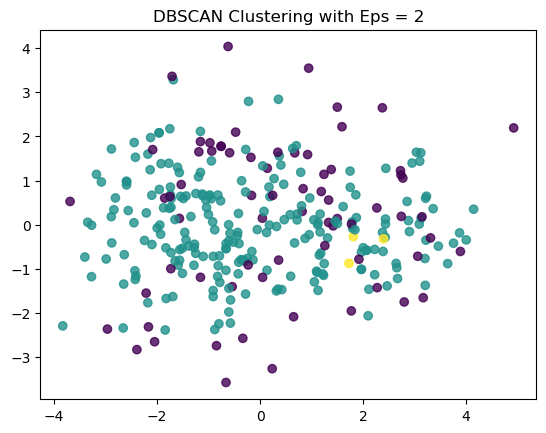

In [34]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

# Apply DBSCAN with the chosen Eps value
eps_value = 2 # Choose based on your observation from the graph
dbscan = DBSCAN(eps=eps_value, min_samples=MinPts)

# Fit the model
dbscan_labels = dbscan.fit_predict(X_scaled)

# Visualize the clusters using PCA for dimensionality reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='viridis', alpha=0.8)
plt.title(f'DBSCAN Clustering with Eps = {eps_value}')
plt.show()

#### Performance Evaluation

In [35]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Silhouette Score
# Only calculate if more than 1 cluster is found
if len(set(dbscan_labels)) > 1:
    non_noise_points = dbscan_labels != -1  # Exclude noise points
    silhouette_avg = silhouette_score(X_scaled[non_noise_points], dbscan_labels[non_noise_points])
    print(f'Silhouette Score: {silhouette_avg:.4f}')
else:
    print("Silhouette Score cannot be calculated (only one cluster or noise).")

# Calinski-Harabasz Index
calinski_harabasz = calinski_harabasz_score(X_scaled, dbscan_labels)
print(f'Calinski-Harabasz Index: {calinski_harabasz:.4f}')

# Davies-Bouldin Index
davies_bouldin = davies_bouldin_score(X_scaled, dbscan_labels)
print(f'Davies-Bouldin Index: {davies_bouldin:.4f}')


Silhouette Score: 0.1215
Calinski-Harabasz Index: 6.1201
Davies-Bouldin Index: 3.9388


In [36]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, fowlkes_mallows_score

# Assuming 'quality' is your ground truth label
true_labels = sample3['quality']  # Replace with the actual ground truth label column

# Adjusted Rand Index
ari_score = adjusted_rand_score(true_labels, dbscan_labels)
print(f'Adjusted Rand Index (ARI): {ari_score}')

# Normalized Mutual Information
nmi_score = normalized_mutual_info_score(true_labels, dbscan_labels)
print(f'Normalized Mutual Information (NMI): {nmi_score}')

# Fowlkes-Mallows Index
fmi_score = fowlkes_mallows_score(true_labels, dbscan_labels)
print(f'Fowlkes-Mallows Index (FMI): {fmi_score}')

Adjusted Rand Index (ARI): 0.0135384981523833
Normalized Mutual Information (NMI): 0.023054733865444273
Fowlkes-Mallows Index (FMI): 0.4668297047331011


## Comparison between K-Means and DBSCAN

k-Means Silhouette Score: 0.1590
DBSCAN Silhouette Score: 0.1215
k-Means Calinski-Harabasz Index: 65.0949
DBSCAN Calinski-Harabasz Index: 6.1201
k-Means Davies-Bouldin Index: 1.9644
DBSCAN Davies-Bouldin Index: 3.9388


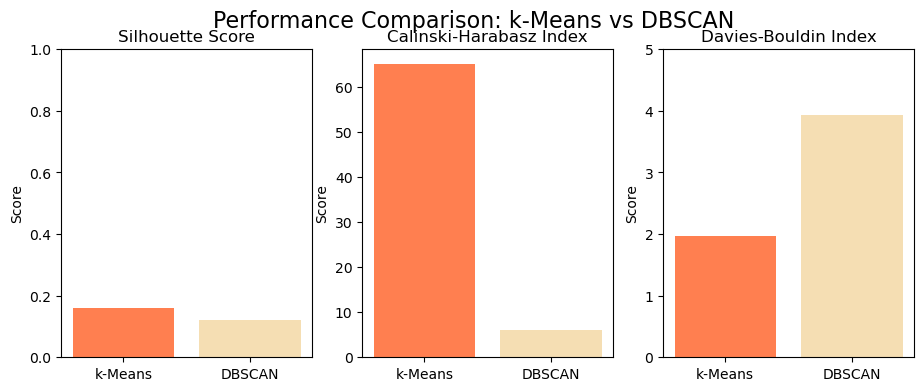

In [40]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt

# Apply k-Means
kmeans = KMeans(n_clusters=3, random_state=42)  # Assuming k=3 as optimal from prior analysis
kmeans_labels = kmeans.fit_predict(X_scaled)

# Apply DBSCAN
dbscan = DBSCAN(eps=2, min_samples=3)  # Using the DBSCAN parameters you worked with
dbscan_labels = dbscan.fit_predict(X_scaled)

# Evaluation Metrics for k-Means
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_ch_index = calinski_harabasz_score(X_scaled, kmeans_labels)
kmeans_db_index = davies_bouldin_score(X_scaled, kmeans_labels)

# Evaluation Metrics for DBSCAN
# Only compute silhouette score if DBSCAN finds more than one cluster
if len(set(dbscan_labels)) > 1:
    dbscan_silhouette = silhouette_score(X_scaled[dbscan_labels != -1], dbscan_labels[dbscan_labels != -1])
else:
    dbscan_silhouette = -1  # Indicate silhouette score is not applicable

dbscan_ch_index = calinski_harabasz_score(X_scaled, dbscan_labels)
dbscan_db_index = davies_bouldin_score(X_scaled, dbscan_labels)

# Store results in a dictionary for easier plotting
results = {
    "Silhouette Score": [kmeans_silhouette, dbscan_silhouette],
    "Calinski-Harabasz Index": [kmeans_ch_index, dbscan_ch_index],
    "Davies-Bouldin Index": [kmeans_db_index, dbscan_db_index]
}


# Print the results for both k-Means and DBSCAN
print(f"k-Means Silhouette Score: {kmeans_silhouette:.4f}")
print(f"DBSCAN Silhouette Score: {dbscan_silhouette:.4f}")

print(f"k-Means Calinski-Harabasz Index: {kmeans_ch_index:.4f}")
print(f"DBSCAN Calinski-Harabasz Index: {dbscan_ch_index:.4f}")

print(f"k-Means Davies-Bouldin Index: {kmeans_db_index:.4f}")
print(f"DBSCAN Davies-Bouldin Index: {dbscan_db_index:.4f}")

# Plotting the results for comparison
labels = ['k-Means', 'DBSCAN']

fig, ax = plt.subplots(1, 3, figsize=(11, 4))

# Silhouette Score
ax[0].bar(labels, results['Silhouette Score'], color=['coral', 'wheat'])
ax[0].set_title('Silhouette Score')
ax[0].set_ylim([0, 1])
ax[0].set_ylabel('Score')

# Calinski-Harabasz Index
ax[1].bar(labels, results['Calinski-Harabasz Index'], color=['coral', 'wheat'])
ax[1].set_title('Calinski-Harabasz Index')
ax[1].set_ylabel('Score')

# Davies-Bouldin Index
ax[2].bar(labels, results['Davies-Bouldin Index'], color=['coral', 'wheat'])
ax[2].set_title('Davies-Bouldin Index')
ax[2].set_ylim([0, 5])
ax[2].set_ylabel('Score')

plt.suptitle('Performance Comparison: k-Means vs DBSCAN', fontsize=16)
plt.show()